# Thomson scattering from discretized distribution functions — `thomson.py`

`thomson.py` is a **self-contained** forward model (numpy + scipy only, no
imports from the `ThomsonScattering` package).  You hand it a 1-D velocity
distribution function **`f(v)` as a discrete numpy array in SI units** — not a
normalized `g(v*)` on a dimensionless velocity — and it returns the collective
Thomson spectrum.

**What `f(v)` means.** It is the 1-D distribution *reduced along the scattering
wavevector* $\hat k$ (integrate the full 3-D $f$ over the two perpendicular
velocity components).  `v` is that parallel component in m/s, in the lab frame,
so a drift/flow along $\hat k$ is just baked into where `f` sits on the axis.
You never pass a temperature or a drift — **the shape of `f(v)` is the whole
story**; only density (which sets the plasma frequency) and ion charge/mass are
needed as scalars.

The pole in the susceptibility integral
$\chi_s = \dfrac{\omega_{p,s}^2}{k^2}\Big[\;\mathcal{P}\!\!\int\dfrac{f_s'(v)}{v_\phi-v}\,dv \;+\; i\pi f_s'(v_\phi)\Big]$
is handled by singularity subtraction on a uniform grid, so it stays accurate
even for a discrete array and even when $v_\phi=\omega/k$ lands between grid
points or far out in the tail.

This tour:
1. Building discretized `f(v)` in SI velocity space
2. An ion-acoustic (IAW) spectrum with the one-line wrapper
3. **Arbitrary** ion distributions (kappa, counter-streaming, hand-built)
4. Electron-plasma-wave (EPW) spectra + the velocity-grid coverage rule
5. The pole integrator / susceptibility on its own
6. A time-resolved streak from `(Nt, Nv)` arrays
7. A multi-species plasma with a time-varying electron distribution
8. Cross-check against the `ThomsonScattering` package

In [1]:
import os, sys
sys.path.insert(0, os.getcwd())          # make thomson.py importable

import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import m_e, m_p

import thomson as ts

# Probe + geometry: 263.25 nm, 60-degree scattering (matches the example decks).
probe_wavelength = 263.25e-9
scattering_angle = ts.scattering_angle_from_vectors(
    probe_vec=[0.0, 0.0, 1.0],
    scatter_vec=[np.sin(np.deg2rad(60.0)), 0.0, np.cos(np.deg2rad(60.0))],
)
print(f"scattering angle = {np.rad2deg(scattering_angle):.1f} deg")

ne = 6e19 * 1e6     # 6e19 cm^-3 -> 6e25 m^-3  (electron density)

scattering angle = 60.0 deg


## 1. Build discretized `f(v)` in SI units

Everything downstream just needs an array `f` and its velocity grid `v` (m/s).
`thomson.py` ships a few convenience builders (`maxwellian_f`, `kappa_f`,
`bi_maxwellian_f`, `super_gaussian_f`) that return properly-normalized `f(v)`,
but you are free to pass **any** array you like (see §3).

Electrons and ions live on their own velocity grids — the thermal speeds differ
by $\sqrt{m_i/m_e}$.  Note the electron grid is deliberately wide (about
$\pm 10\,v_{th}$): the EPW resonance sits far out in the tail, and the spectrum
is only as good as your grid's coverage there (more on that in §4).

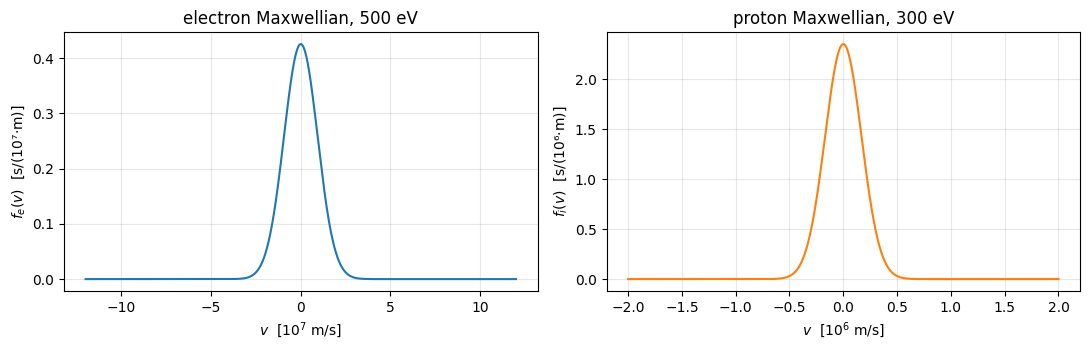

area check  integral f_e dv = 1.0    integral f_i dv = 1.0


In [2]:
# electron grid: wide enough to resolve the EPW tail (~10 v_th at 350 eV)
ve = np.linspace(-1.2e8, 1.2e8, 12001)
# ion grid: thermal protons at a few hundred eV
vi = np.linspace(-2.0e6, 2.0e6, 4001)

Te, Ti = 500.0, 300.0                       # eV
fe = ts.maxwellian_f(ve, Te, m_e)           # normalized: integral f dv = 1
fi = ts.maxwellian_f(vi, Ti, m_p)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(ve / 1e7, fe * 1e7)
ax[0].set_xlabel(r"$v$  [$10^7$ m/s]"); ax[0].set_ylabel(r"$f_e(v)$  [s/(10⁷·m)]")
ax[0].set_title(f"electron Maxwellian, {Te:.0f} eV")
ax[1].plot(vi / 1e6, fi * 1e6, "C1")
ax[1].set_xlabel(r"$v$  [$10^6$ m/s]"); ax[1].set_ylabel(r"$f_i(v)$  [s/(10⁶·m)]")
ax[1].set_title(f"proton Maxwellian, {Ti:.0f} eV")
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("area check  integral f_e dv =", np.trapezoid(fe, ve),
      "   integral f_i dv =", np.trapezoid(fi, vi))

## 2. An ion-acoustic spectrum with the one-line wrapper

`thomson_spectrum(...)` is the convenience entry point for the common
single-electron / single-ion case.  Pass the electron and ion arrays, the
electron density, and the ion charge/mass; quasineutrality sets $n_i=n_e/Z$.
It returns scattered power $P(k,\lambda)$ with shape `(Nwavelength, Ntime)`.

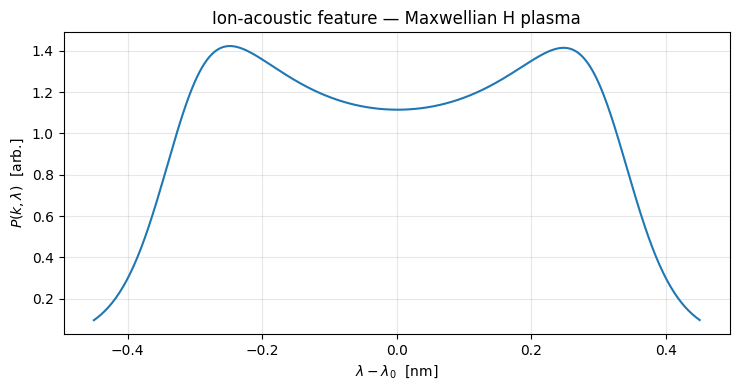

In [3]:
lam = np.linspace(262.8e-9, 263.7e-9, 500)   # IAW window (meters)

P = ts.thomson_spectrum(
    lam, probe_wavelength, scattering_angle,
    fe, ve, ne,              # electrons
    fi, vi, Zi=1.0, Ai=1.0,  # protons
    normalization="none",
)

plt.figure(figsize=(7.5, 4))
plt.plot((lam - probe_wavelength) * 1e9, P[:, 0])
plt.xlabel(r"$\lambda - \lambda_0$  [nm]"); plt.ylabel(r"$P(k,\lambda)$  [arb.]")
plt.title("Ion-acoustic feature — Maxwellian H plasma")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 3. Arbitrary ion distributions — the whole point

Because the input is just an array, the ion distribution can be *anything*.
Here are three ions on the same axis:

* a **Maxwellian** (reference),
* a **$\kappa$ distribution** ($\kappa=3$, suprathermal power-law tails), and
* a **counter-streaming** pair (two proton beams drifting $\pm 4\times10^5$ m/s)
  — trivially built as a sum of two shifted Maxwellians, yet not a member of any
  analytic family.

The $\kappa$ tails fill in the trough between the acoustic resonances; the
counter-streaming beams pull the resonances apart / add structure.

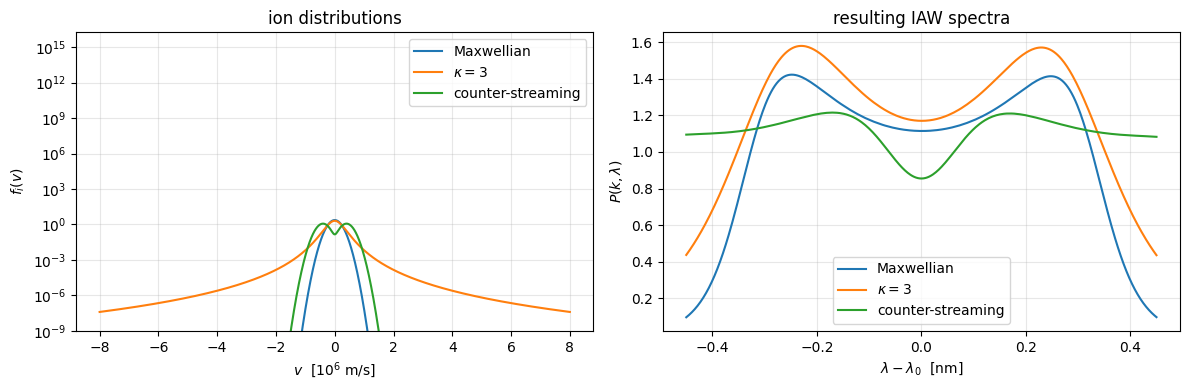

In [4]:
vi_w = np.linspace(-8e6, 8e6, 8001)      # wider grid for tails / beams

fi_max    = ts.maxwellian_f(vi_w, Ti, m_p)
fi_kappa  = ts.kappa_f(vi_w, Ti, m_p, kappa=3.0)
u = 4.0e5
fi_stream = 0.5 * ts.maxwellian_f(vi_w, Ti, m_p, drift=+u) \
          + 0.5 * ts.maxwellian_f(vi_w, Ti, m_p, drift=-u)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for f, lbl in [(fi_max, "Maxwellian"), (fi_kappa, r"$\kappa=3$"),
               (fi_stream, "counter-streaming")]:
    ax[0].plot(vi_w / 1e6, f * 1e6, label=lbl)
    P = ts.thomson_spectrum(lam, probe_wavelength, scattering_angle,
                            fe, ve, ne, f, vi_w, Zi=1.0, Ai=1.0,
                            normalization="none")
    ax[1].plot((lam - probe_wavelength) * 1e9, P[:, 0], label=lbl)
ax[0].set_xlabel(r"$v$  [$10^6$ m/s]"); ax[0].set_ylabel(r"$f_i(v)$")
ax[0].set_title("ion distributions"); ax[0].set_yscale("log")
ax[0].set_ylim(1e-9, None)
ax[1].set_xlabel(r"$\lambda-\lambda_0$  [nm]"); ax[1].set_ylabel(r"$P(k,\lambda)$")
ax[1].set_title("resulting IAW spectra")
for a in ax:
    a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

You really can pass a hand-built array — nothing has to come from a
formula.  Here is a "flat-top" ion distribution defined pointwise
($f\propto 1/(1+(v/v_0)^8)$) and dropped straight in.

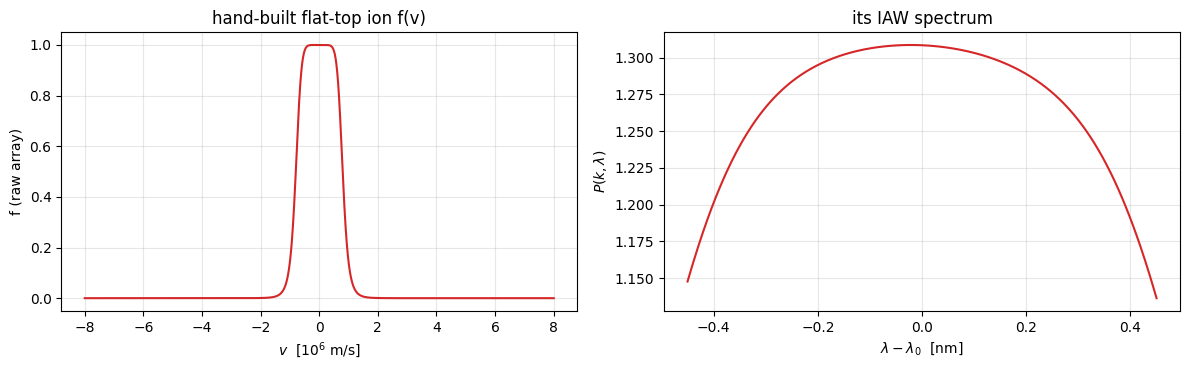

In [5]:
v0 = 8e5
fi_flat = 1.0 / (1.0 + (vi_w / v0) ** 8)     # arbitrary array, un-normalized

P_flat = ts.thomson_spectrum(lam, probe_wavelength, scattering_angle,
                             fe, ve, ne, fi_flat, vi_w, Zi=1.0, Ai=1.0,
                             normalization="none")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(vi_w / 1e6, fi_flat, "C3")
ax[0].set_xlabel(r"$v$  [$10^6$ m/s]"); ax[0].set_ylabel("f (raw array)")
ax[0].set_title("hand-built flat-top ion f(v)")
ax[1].plot((lam - probe_wavelength) * 1e9, P_flat[:, 0], "C3")
ax[1].set_xlabel(r"$\lambda-\lambda_0$  [nm]"); ax[1].set_ylabel(r"$P(k,\lambda)$")
ax[1].set_title("its IAW spectrum")
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. EPW spectra, and the velocity-grid coverage rule

The electron-plasma-wave feature resonates at a **high phase velocity**
$v_\phi \sim 3\text{–}4\,v_{th}$, out where $f_e$ is tiny.  Two consequences:

* the electron grid must *cover* those phase velocities (hence the wide `ve`);
* the feature is exquisitely sensitive to the tail of $f_e$ — a hot-electron
  component shows up as a high-$v_\phi$ shoulder.

Below: a Maxwellian vs a **bi-Maxwellian** (10% hot electrons at $4\times$ the
bulk temperature).

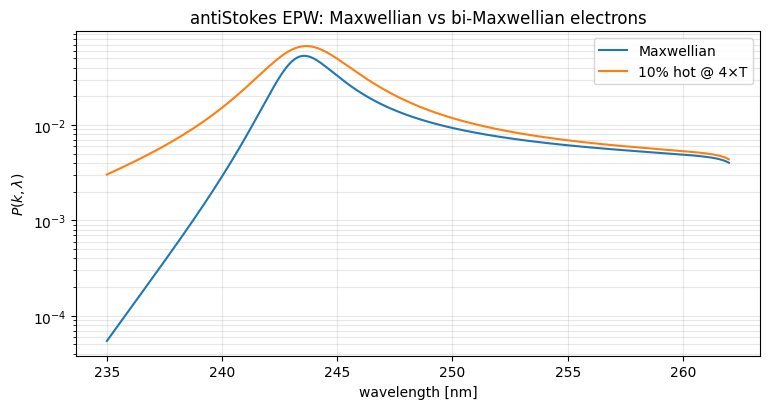

In [6]:
lam_epw = np.linspace(235e-9, 262e-9, 500)   # antiStokes EPW window
Te_epw = 350.0

fe_max = ts.maxwellian_f(ve, Te_epw, m_e)
fe_hot = ts.bi_maxwellian_f(ve, Te_epw, m_e, fhot=0.10, rhot=4.0)

plt.figure(figsize=(7.8, 4.2))
for f, lbl in [(fe_max, "Maxwellian"), (fe_hot, "10% hot @ 4×T")]:
    P = ts.thomson_spectrum(lam_epw, probe_wavelength, scattering_angle,
                            f, ve, ne, fi, vi, Zi=1.0, Ai=1.0,
                            normalization="none")
    plt.semilogy(lam_epw * 1e9, P[:, 0], label=lbl)
plt.xlabel("wavelength [nm]"); plt.ylabel(r"$P(k,\lambda)$")
plt.title("antiStokes EPW: Maxwellian vs bi-Maxwellian electrons")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

**Coverage matters.** Shrink the electron grid so it no longer reaches
the EPW phase velocity and the peak degrades — a diagnostic, not a bug: the
model can only integrate over the `f(v)` you give it.

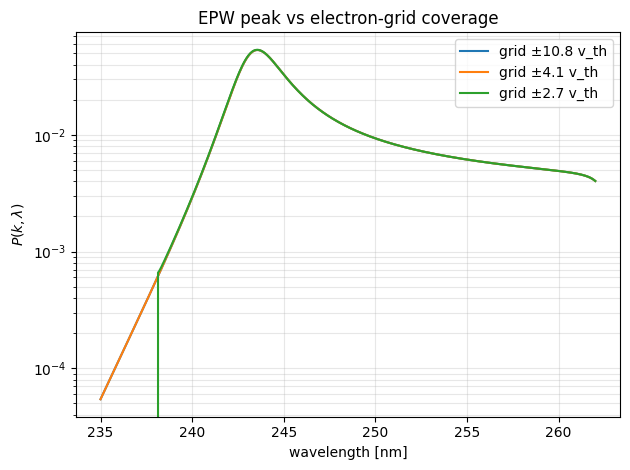

In [7]:
for span in [1.2e8, 4.5e7, 3.0e7]:
    veg = np.linspace(-span, span, 12001)
    feg = ts.maxwellian_f(veg, Te_epw, m_e)
    Pg = ts.thomson_spectrum(lam_epw, probe_wavelength, scattering_angle,
                             feg, veg, ne, fi, vi, normalization="none")
    vth = np.sqrt(2 * Te_epw * 1.602176634e-19 / m_e)
    plt.semilogy(lam_epw * 1e9, Pg[:, 0],
                 label=f"grid ±{span/vth:.1f} v_th")
plt.xlabel("wavelength [nm]"); plt.ylabel(r"$P(k,\lambda)$")
plt.title("EPW peak vs electron-grid coverage")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

## 5. The pole integrator on its own

`dispersion_integral(vp, v, f)` returns the complex kernel
$Z(v_\phi)=\mathcal{P}\!\int \frac{f'(v)}{v_\phi-v}\,dv + i\pi f'(v_\phi)$
directly from a discretized `f`.  The imaginary part is $\pi f'(v_\phi)$ — the
Landau resonance — and the real part is the Hilbert transform that shapes the
dispersion.  This is the machinery underneath every susceptibility above.

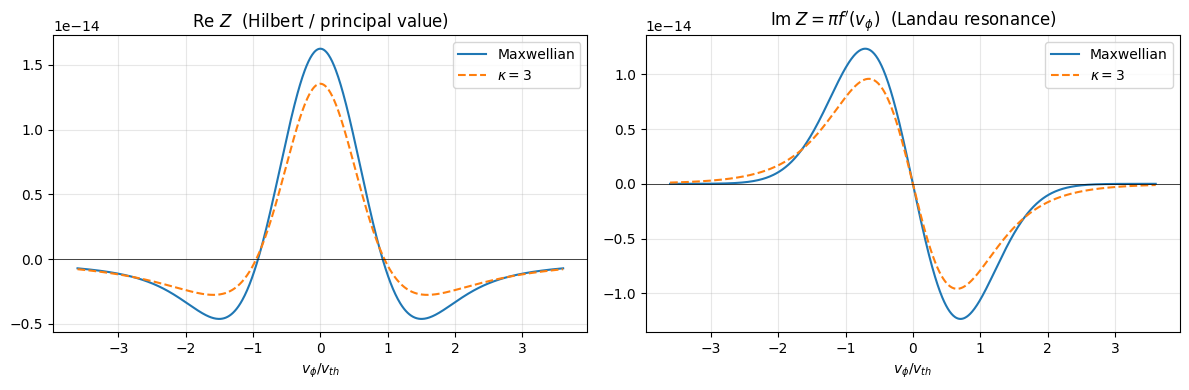

electron plasma freq = 4.370e+14 rad/s,  k ~ 2.387e+07 1/m
max |Im chi_e| (Landau damping strength) = 4.139e+00


In [8]:
vp = np.linspace(-4e7, 4e7, 800)        # query phase velocities (m/s)
vth_e = np.sqrt(2 * 350.0 * 1.602176634e-19 / m_e)
fe350 = ts.maxwellian_f(ve, 350.0, m_e)

Zmax = ts.dispersion_integral(vp, ve, fe350)
Zkap = ts.dispersion_integral(vp, ve, ts.kappa_f(ve, 350.0, m_e, kappa=3.0))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(vp / vth_e, Zmax.real, label="Maxwellian")
ax[0].plot(vp / vth_e, Zkap.real, "--", label=r"$\kappa=3$")
ax[0].set_title(r"Re $Z$  (Hilbert / principal value)")
ax[1].plot(vp / vth_e, Zmax.imag, label="Maxwellian")
ax[1].plot(vp / vth_e, Zkap.imag, "--", label=r"$\kappa=3$")
ax[1].set_title(r"Im $Z = \pi f'(v_\phi)$  (Landau resonance)")
for a in ax:
    a.set_xlabel(r"$v_\phi / v_{th}$"); a.axhline(0, color="k", lw=0.5)
    a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# turn it into a susceptibility: chi = wp^2 / k^2 * Z
from scipy.constants import e as qe, epsilon_0
wpe2 = ne * qe**2 / (m_e * epsilon_0)
k_typical = 4 * np.pi / probe_wavelength * np.sin(scattering_angle / 2)
chi_e = wpe2 / k_typical**2 * Zmax
print(f"electron plasma freq = {np.sqrt(wpe2):.3e} rad/s,  k ~ {k_typical:.3e} 1/m")
print(f"max |Im chi_e| (Landau damping strength) = {np.abs(chi_e.imag).max():.3e}")

## 6. Time-resolved streak from `(Nt, Nv)` arrays

Pass `f` as a 2-D array and every time step gets its own distribution.  Here the
ions evolve over 12 time steps: $T_i$ ramps $150\!\to\!450$ eV while the
$\kappa$ index falls $6\!\to\!2$ (tails fatten).  The result is a streak
$P(k,\lambda,t)$ — exactly what a streaked spectrometer records.

ion distribution array shape (Nt, Nv): (12, 8001)


streak shape (Nwavelength, Nt): (500, 12)


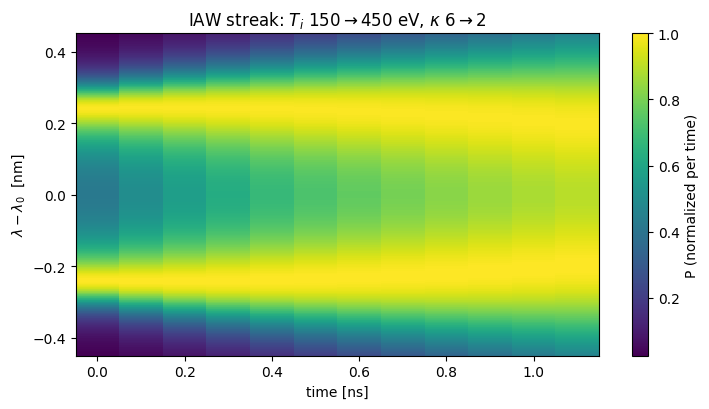

In [9]:
# --- self-contained: this cell reproduces its output with no other cells ---
import os, sys
sys.path.insert(0, os.getcwd())              # so `import thomson` finds thomson.py
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import m_e, m_p
import thomson as ts

# probe + 60-degree scattering geometry
probe_wavelength = 263.25e-9
scattering_angle = ts.scattering_angle_from_vectors(
    probe_vec=[0.0, 0.0, 1.0],
    scatter_vec=[np.sin(np.deg2rad(60.0)), 0.0, np.cos(np.deg2rad(60.0))])

ne = 6e19 * 1e6                              # electron density [m^-3]
Te = 500.0                                   # electron temperature [eV]

# electron background: Maxwellian on a wide velocity grid (shared across time)
ve = np.linspace(-1.2e8, 1.2e8, 12001)
fe = ts.maxwellian_f(ve, Te, m_e)

lam  = np.linspace(262.8e-9, 263.7e-9, 500)  # IAW wavelength window [m]
vi_w = np.linspace(-8e6, 8e6, 8001)          # ion velocity grid [m/s]

# --- time-varying ion distribution: kappa distribution ramping over time ---
Nt = 12
Ti_t  = np.linspace(150.0, 450.0, Nt)        # ion temperature ramp [eV]
kap_t = np.linspace(6.0, 2.0, Nt)            # kappa index ramp (tails fatten)

fi_t = np.stack([ts.kappa_f(vi_w, Ti_t[j], m_p, kappa=kap_t[j])
                 for j in range(Nt)])            # (Nt, Nv)
print("ion distribution array shape (Nt, Nv):", fi_t.shape)

P_streak = ts.thomson_spectrum(
    lam, probe_wavelength, scattering_angle,
    fe, ve, ne,            # electrons: 1-D array -> shared across time
    fi_t, vi_w,            # ions: (Nt, Nv) -> one per time step
    Zi=1.0, Ai=1.0,
    normalization="max",   # per-time-column, like a normalized streak
)
print("streak shape (Nwavelength, Nt):", P_streak.shape)

t = np.linspace(0.0, 1.1, Nt)
plt.figure(figsize=(7.5, 4.2))
plt.pcolormesh(t, (lam - probe_wavelength) * 1e9, P_streak, shading="auto")
plt.colorbar(label="P (normalized per time)")
plt.xlabel("time [ns]"); plt.ylabel(r"$\lambda-\lambda_0$  [nm]")
plt.title(r"IAW streak: $T_i$ 150$\to$450 eV, $\kappa$ 6$\to$2")
plt.tight_layout(); plt.show()

## 7. Multi-species plasma with a time-varying electron distribution

The full API — `spectral_density` / `scattered_power` — takes **lists** of
`Species`, so a plasma can carry several ion species alongside one (or more)
electron populations, each with its own `f(v)` array and velocity grid.

Here a **CH plasma** (protons $Z=1,A=1$ and carbon $Z=6,A=12$ in a 1:1 number
mix, quasineutral so $Z_H n_H + Z_C n_C = n_e \Rightarrow 7n_H = n_e$) is probed
while the **electron distribution itself evolves in time**: the bulk temperature
ramps $300\!\to\!900$ eV and a hot-electron fraction grows $0\!\to\!12\%$.  The
electron array is 2-D, `(Nt, Nv)`; the (static) ion arrays are 1-D and simply
broadcast across time — mixing time-dependent and time-independent species is
fine.

Two ion-acoustic features appear — a fast proton mode and a slower carbon mode
(acoustic speed $\sim\!\sqrt{Z T_e/m_i}$) — and both walk outward as the
electrons heat.

electron distribution array shape (Nt, Nv): (14, 12001)


streak shape (Nwavelength, Nt): (600, 14)


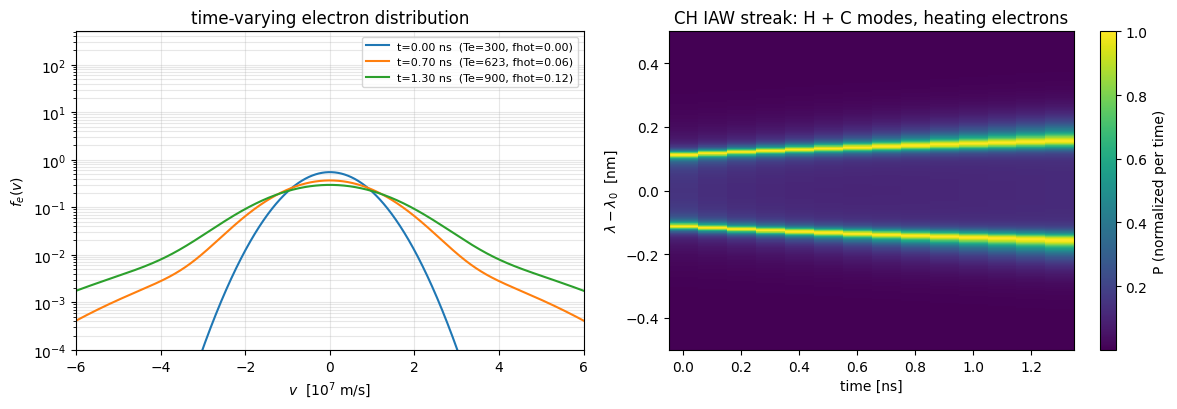

In [10]:
Nt2 = 14
Te_t   = np.linspace(300.0, 900.0, Nt2)     # electron bulk temperature ramp [eV]
fhot_t = np.linspace(0.0, 0.12, Nt2)        # hot-electron fraction ramp

# time-varying electron distribution -> shape (Nt, Nv)
fe_t = np.stack([ts.bi_maxwellian_f(ve, Te_t[j], m_e, fhot=fhot_t[j], rhot=5.0)
                 for j in range(Nt2)])
print("electron distribution array shape (Nt, Nv):", fe_t.shape)

# CH ion mix (1:1 number), quasineutrality -> n_H = n_C = n_e / 7
nH = nC = ne / 7.0
Ti_ch = 200.0                               # ion temperature [eV], fixed

vH = np.linspace(-3.0e6, 3.0e6, 4001)
vC = np.linspace(-1.0e6, 1.0e6, 4001)       # carbon is heavier -> slower
fH = ts.maxwellian_f(vH, Ti_ch, m_p)        # 1-D arrays: shared across time
fC = ts.maxwellian_f(vC, Ti_ch, 12 * m_p)

electrons = [ts.Species.electron(fe_t, ve, ne)]        # time-varying (Nt, Nv)
ions = [
    ts.Species.ion(fH, vH, nH, Z=1.0, A=1.0),          # protons
    ts.Species.ion(fC, vC, nC, Z=6.0, A=12.0),         # carbon C6+
]

lam_ch = np.linspace(262.75e-9, 263.75e-9, 600)
P_ch = ts.scattered_power(lam_ch, probe_wavelength, scattering_angle,
                          electrons, ions, normalization="max")
print("streak shape (Nwavelength, Nt):", P_ch.shape)

t2 = np.linspace(0.0, 1.3, Nt2)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for j in [0, Nt2 // 2, Nt2 - 1]:
    ax[0].semilogy(ve / 1e7, fe_t[j] * 1e7,
                   label=f"t={t2[j]:.2f} ns  (Te={Te_t[j]:.0f}, fhot={fhot_t[j]:.2f})")
ax[0].set_xlabel(r"$v$  [$10^7$ m/s]"); ax[0].set_ylabel(r"$f_e(v)$")
ax[0].set_xlim(-6, 6); ax[0].set_ylim(1e-4, None)
ax[0].set_title("time-varying electron distribution")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3, which="both")

pm = ax[1].pcolormesh(t2, (lam_ch - probe_wavelength) * 1e9, P_ch, shading="auto")
fig.colorbar(pm, ax=ax[1], label="P (normalized per time)")
ax[1].set_xlabel("time [ns]"); ax[1].set_ylabel(r"$\lambda-\lambda_0$  [nm]")
ax[1].set_title("CH IAW streak: H + C modes, heating electrons")
plt.tight_layout(); plt.show()

## 8. Cross-check against the `ThomsonScattering` package

`thomson.py` is standalone, but its formulas are the same physics as the parent
package — just expressed in physical velocity and evaluated from a discretized
`f` instead of an analytic `g`.  Feeding a discretized Maxwellian / $\kappa$
here reproduces the package's analytic path to **quadrature accuracy** (the
residual is set by grid resolution, not by any modelling difference).

In [11]:
try:
    import jax
    jax.config.update("jax_enable_x64", True)
    import jax.numpy as jnp
    from scipy.constants import e as qe, k as kB
    from ThomsonScattering.distributions import resolve_distribution
    from ThomsonScattering.forward import spectral_density as pkg_Skw
    eV = qe / kB
    geom = dict(probe_wavelength=probe_wavelength,
                probe_vec=jnp.array([0., 0., 1.]),
                scatter_vec=jnp.array([np.sin(scattering_angle), 0.,
                                       np.cos(scattering_angle)]),
                ue_dir=jnp.array([1., 0., 0.]), ui_dir=jnp.array([1., 0., 0.]))
    mx = resolve_distribution("maxwellian")
    kp = resolve_distribution("kappa")

    def pkg(lamx, Tex, Tix, imodel, ishape):
        return np.asarray(pkg_Skw(
            e_models=(mx,), i_models=(imodel,), e_shapes=((),), i_shapes=(ishape,),
            n=jnp.array([ne]), ue=jnp.zeros((1, 1)), ui=jnp.zeros((1, 1)),
            Te=jnp.full((1, 1), Tex * eV), Ti=jnp.full((1, 1), Tix * eV),
            efract=jnp.ones((1, 1)), ifract=jnp.ones((1, 1)),
            ion_z=jnp.array([1.]), ion_a=jnp.array([1.]),
            wavelengths=jnp.asarray(lamx), **geom))

    def rel(a, b):
        a, b = np.asarray(a).ravel(), np.asarray(b).ravel()
        return np.linalg.norm(a - b) / np.linalg.norm(b)

    # IAW Maxwellian
    mine = ts.thomson_spectrum(lam, probe_wavelength, scattering_angle,
                               fe, ve, ne, fi, vi, return_skw=True)
    print(f"IAW  Maxwellian  S(k,w) L2 rel error = "
          f"{rel(mine, pkg(lam, Te, Ti, mx, ())):.2e}")

    # IAW kappa=3
    mine_k = ts.thomson_spectrum(lam, probe_wavelength, scattering_angle,
                                 fe, ve, ne, fi_kappa, vi_w, return_skw=True)
    print(f"IAW  kappa=3     S(k,w) L2 rel error = "
          f"{rel(mine_k, pkg(lam, Te, Ti, kp, (jnp.array([3.0]),))):.2e}")

    # EPW Maxwellian
    mine_e = ts.thomson_spectrum(lam_epw, probe_wavelength, scattering_angle,
                                 fe_max, ve, ne, fi, vi, return_skw=True)
    print(f"EPW  Maxwellian  S(k,w) L2 rel error = "
          f"{rel(mine_e, pkg(lam_epw, Te_epw, Ti, mx, ())):.2e}")
except Exception as exc:
    print("package not available for cross-check:", exc)

IAW  Maxwellian  S(k,w) L2 rel error = 3.05e-06


IAW  kappa=3     S(k,w) L2 rel error = 3.06e-05
EPW  Maxwellian  S(k,w) L2 rel error = 1.03e-05
